In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [5]:
tf.__version__

'2.19.1'

In [6]:
# load Fashion MNIST dataset
# dataset is a collection of 60,000 28x28 grayscale images of clothing, along with labels.
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

# normalize the images to a range of 0 to 1
train_images, test_images = train_images / 255.0, test_images / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 1s 22us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 21s 1us/step 
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step 


In [10]:
# build model
model = tf.keras.models.Sequential([
    # Flatten the 28x28 image into a 1D array
    layers.Flatten(input_shape=(28, 28)),
    
    # First hidden layer with 128 neurons
    layers.Dense(128, activation="relu"),

    # Second hidden layer with 64 neurons
    layers.Dense(64, activation="relu"),

    # Output layer with 10 neurons (one per class)
    layers.Dense(10, activation="softmax")
])

# compile the model with the Adam optimizer, 
# sparse categorical crossentropy loss function (since we have multiple classes), 
# and accuracy as our metric.
model.compile(optimizer="adam",
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

In [11]:
# train model
history = model.fit(train_images, train_labels, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7711 - loss: 0.6561 - val_accuracy: 0.8361 - val_loss: 0.4441
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8566 - loss: 0.3874 - val_accuracy: 0.8537 - val_loss: 0.4069
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8742 - loss: 0.3374 - val_accuracy: 0.8737 - val_loss: 0.3628
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8792 - loss: 0.3278 - val_accuracy: 0.8638 - val_loss: 0.3690
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8905 - loss: 0.2953 - val_accuracy: 0.8824 - val_loss: 0.3286


In [13]:
# evaluate model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8735 - loss: 0.3432 
Test Accuracy: 0.87


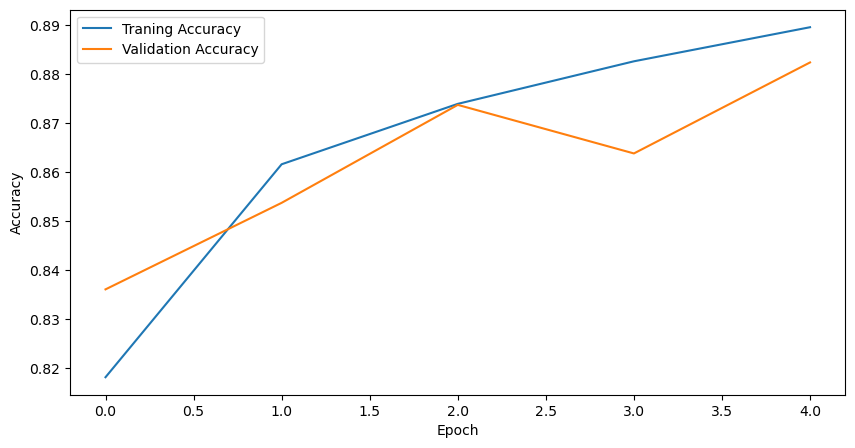

In [14]:
import matplotlib.pyplot as plt

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()